This notebook demonstrates how to use `plot_pass_selection_embed` from `code/viz_pass_selection.py` to visualize pass selection predictions from a trained model with player embeddings.

In [1]:
import sys, os
import torch
import random

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "code"))

from soccermap.statsbomb_io import load_events, load_threesixty, load_lineups
from soccermap.expand import build_expanded_dfs
from soccermap.dataset import PassDataset
from soccermap.model import SoccerMapWithPlayerEmbed, SoccerMapConfig
from viz_pass_selection import plot_pass_selection_embed

In [2]:
# ---- Load match data ----
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "leverkusen_data")
MATCH_ID = "3895348"
CKPT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", "pass_selection_demo.pt")

events = load_events(DATA_ROOT, MATCH_ID)
threesixty = load_threesixty(DATA_ROOT, MATCH_ID)
lineups = load_lineups(DATA_ROOT, MATCH_ID)
m = build_expanded_dfs(events, threesixty, lineups)

ds = PassDataset(m.expanded_df, compute_velocities=False, only_passes=True, team_filter="Bayer Leverkusen")
print(f"Total pass samples: {len(ds)}")

Total pass samples: 676


In [3]:
# ---- Load model from checkpoint ----
ckpt = torch.load(CKPT_PATH, map_location="cpu")
player_id_mapping = ckpt["player_id_mapping"]

model = SoccerMapWithPlayerEmbed(
    num_players=ckpt["num_players"],
    embed_dim=ckpt["embed_dim"],
    cfg=SoccerMapConfig(),
)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Model loaded — {ckpt['num_players']} players, embed_dim={ckpt['embed_dim']}")

Model loaded — 29 players, embed_dim=8


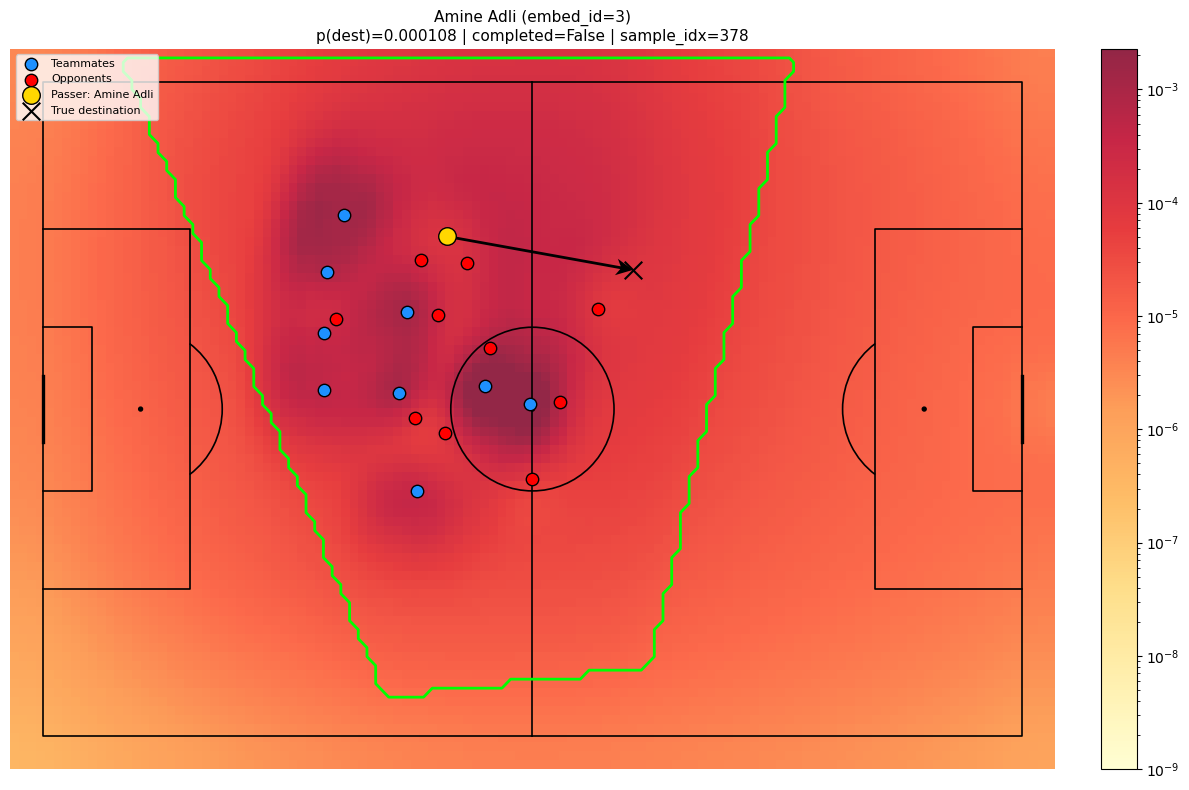

In [4]:
SWAP_PLAYER = "Granit Xhaka"

# ---- Actual passer's prediction ----
plot_pass_selection_embed(
    model, ds, m.expanded_df, player_id_mapping,
    sample_idx=378,
);

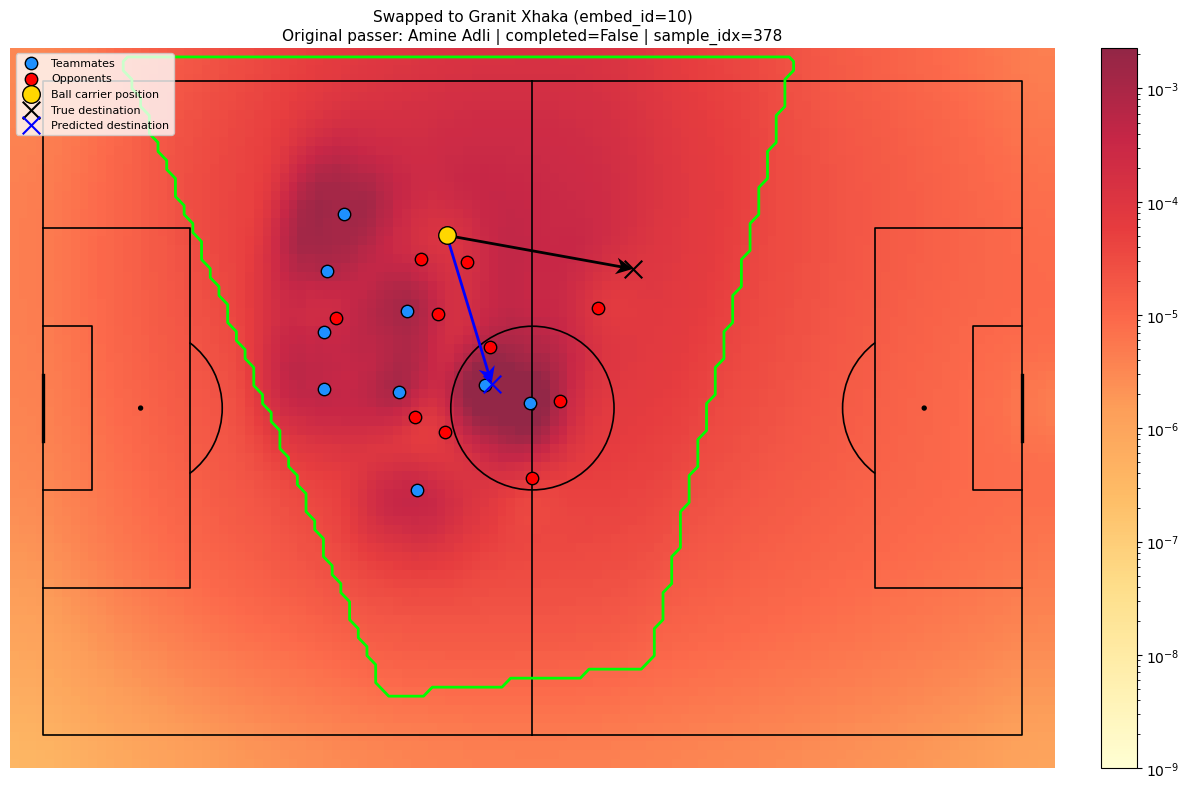

In [5]:
plot_pass_selection_embed(
    model, ds, m.expanded_df, player_id_mapping,
    sample_idx=378,
    swap_player=SWAP_PLAYER,
);
